<a href="https://colab.research.google.com/github/Somrat390/Pytorch/blob/main/Neural_Network_with_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pytorch Workflow

In [1]:
import torch
from torch import nn ## nn is the building block of neural network
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cpu'

# Data(Preparing and loading)

In [2]:
# Create *known* parameter

weight = 0.7
bias = 0.3

#create data
start = 0
end = 1
step = 0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)

y = weight * X + bias

X[:10], y[:10], len(X), len(y)

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]),
 50,
 50)

# Splitting data into training and testing dataset

In [3]:
train_split = int(0.8 * len(X))
X_train,y_train=X[:train_split] , y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [4]:
X_train, y_train

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260],
         [0.4400],
         [0.4540],
         [

In [5]:
def plot_prediction(train_data = X_train,train_labels= y_train,test_data=X_test,test_labels=y_test,prediction=None):
  plt.figure(figsize=(10,7))

  plt.scatter(train_data,train_labels, c="b", s=4, label="Trainig data")

  plt.scatter(test_data,test_labels,c="g", s=4, label="Testing data")


  if prediction is not None:

    plt.scatter(test_data,prediction,c="r",s=4,label="Predictions")

  plt.legend(prop={"size": 14})

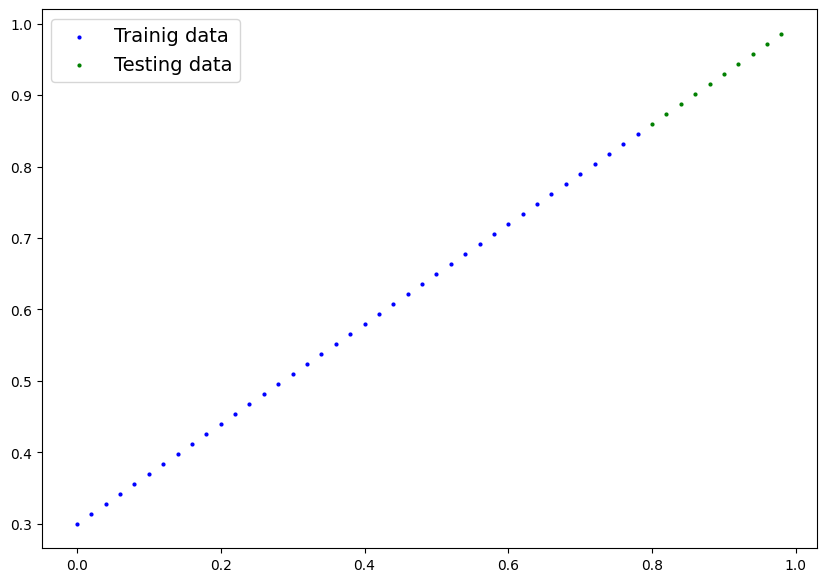

In [6]:
plot_prediction()

# Model building

In [7]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(
        1,requires_grad=True,dtype=torch.float
    ))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))

  def forward(self, x:torch.Tensor) -> torch.Tensor:
      return self.weights * x + self.bias



In [28]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [26]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [10]:
weight, bias

(0.7, 0.3)

In [11]:
# Making prediction
with torch.inference_mode():
  y_pred = model_0(X_test)

y_pred

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [12]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

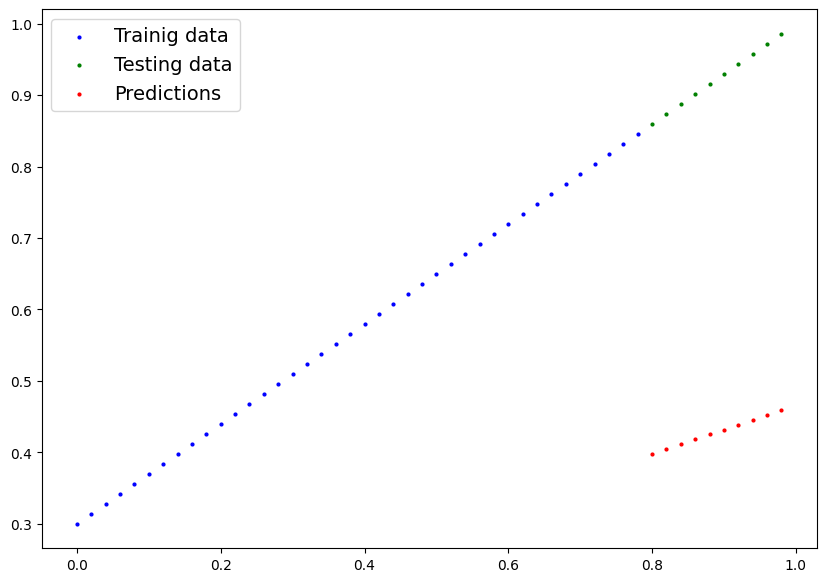

In [13]:
plot_prediction(prediction=y_pred)

In [29]:
# Setup a loss funtion
loss_fn = nn.L1Loss()

#setting optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

# Training loop
- Loop through data
- Forward Pass
- calculate loss
- oprimizer zero grad
- Backpropagation
- improve loss

In [30]:

torch.manual_seed(42)
# Training loop
epochs = 200

#Track diffrent values
epoch_count = []
loss_values = []
test_loss_values = []

# Training
for epoch in range(epochs):
  model_0.train() # train mode in pytorch sets all parameter that require gradients

  y_pred = model_0(X_train) #forward pass

  loss = loss_fn(y_pred, y_train) # calculate loss
  print(f"Loss {loss}")
  optimizer.zero_grad() #optimizer to zero grad

  loss.backward() # backpropagation

  optimizer.step() #performing gradient descent

  model_0.eval() # turn off gradient tracking
  with torch.inference_mode():
      y_pred = model_0(X_test)

      test_loss = loss_fn(y_pred, y_test)

  if epoch%10 == 0:
       epoch_count.append(epoch)
       loss_values.append(loss)
       test_loss_values.append(test_loss)
       print(f"Epoc: {epoch} | Loss{loss} | Test loss{test_loss}")
       print(model_0.state_dict())


Loss 0.31288138031959534
Epoc: 0 | Loss0.31288138031959534 | Test loss0.48106518387794495
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Loss 0.3013603389263153
Loss 0.28983935713768005
Loss 0.2783183455467224
Loss 0.26679736375808716
Loss 0.2552763521671295
Loss 0.24375534057617188
Loss 0.23223432898521423
Loss 0.22071333229541779
Loss 0.20919232070446014
Loss 0.1976713240146637
Epoc: 10 | Loss0.1976713240146637 | Test loss0.3463551998138428
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
Loss 0.18615034222602844
Loss 0.1746293306350708
Loss 0.16310831904411316
Loss 0.1515873372554779
Loss 0.14006635546684265
Loss 0.1285453587770462
Loss 0.11702437698841095
Loss 0.1060912236571312
Loss 0.09681284427642822
Loss 0.08908725529909134
Epoc: 20 | Loss0.08908725529909134 | Test loss0.21729660034179688
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
Loss 0.08227583020925522
Loss 0.07638873159885406
Loss 0.07160007208585739
Loss 0

In [16]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [17]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.5784])), ('bias', tensor([0.3513]))])

In [18]:
weight, bias

(0.7, 0.3)

In [31]:
with torch.inference_mode():
  y_pred = model_0(X_test)

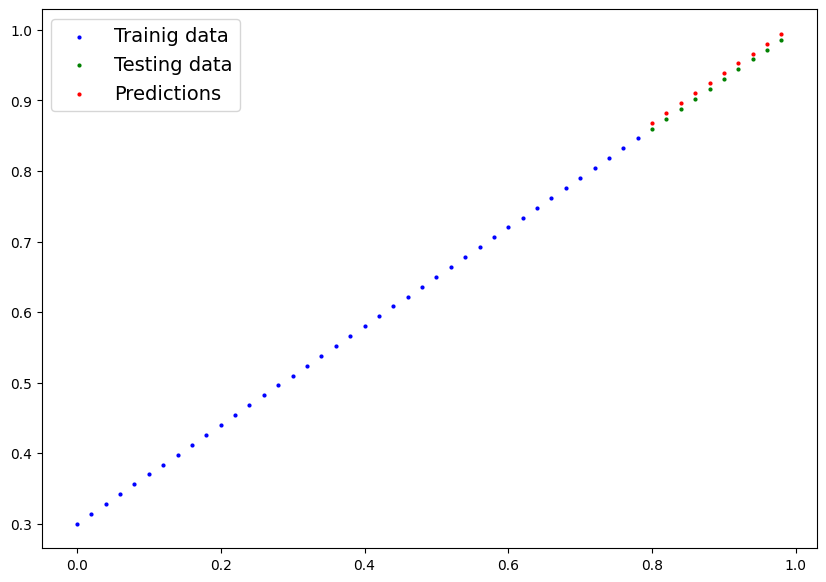

In [32]:
plot_prediction(prediction=y_pred)

In [37]:
loss_values, test_loss_values

([tensor(0.3129, grad_fn=<MeanBackward0>),
  tensor(0.1977, grad_fn=<MeanBackward0>),
  tensor(0.0891, grad_fn=<MeanBackward0>),
  tensor(0.0531, grad_fn=<MeanBackward0>),
  tensor(0.0454, grad_fn=<MeanBackward0>),
  tensor(0.0417, grad_fn=<MeanBackward0>),
  tensor(0.0382, grad_fn=<MeanBackward0>),
  tensor(0.0348, grad_fn=<MeanBackward0>),
  tensor(0.0313, grad_fn=<MeanBackward0>),
  tensor(0.0279, grad_fn=<MeanBackward0>),
  tensor(0.0245, grad_fn=<MeanBackward0>),
  tensor(0.0210, grad_fn=<MeanBackward0>),
  tensor(0.0176, grad_fn=<MeanBackward0>),
  tensor(0.0142, grad_fn=<MeanBackward0>),
  tensor(0.0107, grad_fn=<MeanBackward0>),
  tensor(0.0073, grad_fn=<MeanBackward0>),
  tensor(0.0039, grad_fn=<MeanBackward0>),
  tensor(0.0089, grad_fn=<MeanBackward0>),
  tensor(0.0089, grad_fn=<MeanBackward0>),
  tensor(0.0089, grad_fn=<MeanBackward0>)],
 [tensor(0.4811),
  tensor(0.3464),
  tensor(0.2173),
  tensor(0.1446),
  tensor(0.1136),
  tensor(0.0992),
  tensor(0.0889),
  tensor(0.08

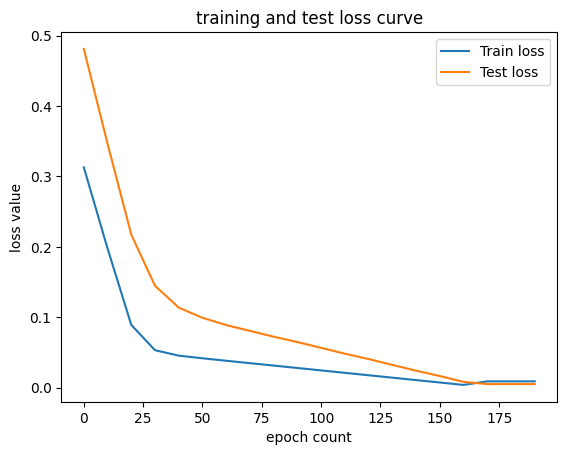

In [38]:
import numpy as np

# plot the loss curves
plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values,label="Test loss")
plt.title("training and test loss curve")
plt.xlabel("epoch count")
plt.ylabel("loss value")
plt.legend()